# Veryfing UOT Count Bias
UOT seems to show decent clustering ability. However, in this previous analysis, one outlier worsened results for CD8+ T cells specifically. This matrix seemed denser than the others, warranting a check on UOT bias towards differing counts.

## Imports

In [ ]:
### Imports ###
# Enabaling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, hic_mask_threshold

# Setting directories
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT'
metadata_save = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT/Metadata'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [ ]:
def map_cell_types(data: pd.DataFrame, cell_type_map: pd.DataFrame):
    '''
        Transforms file name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).
        cell_type_map : pd.DataFrame
            Dataframe mapping file names to cell types.

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = cell_type_map.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int, gamma: float = None, reg_m : float|None = None):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        gamma : float
            Distance scaling parameter.
            Default = None, looks for unscaled data.
        reg_m : float
            Unbalanced parameter used.
            Default = None, looks for balanced data.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))

    #if gamma is None:
    #    pattern = re.compile(
    #        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}\.csv$"
    #    )
    #else:
    
    if reg_m is None:
        pattern = re.compile(
            rf"^balanced_(.*?)_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
        )
    else:
        pattern = re.compile(
            rf"^unbalanced_reg_m={reg_m}_(.*?)_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
        )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df, metadata))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

def add_mass_to_long_df(long_df: pd.DataFrame, total_mass: pd.DataFrame):
    '''
        Adds total mass to long format dataframe.
        Assumes total_mass to be formatted as generated in this notebook.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe with OT data.
        total_mass : pd.DataFrame
            Dataframe with file names and masses.
        
        Returns
        -------
        long_df_mass : pd.DataFrame
            Long format dataframe with added mass metadata columns
    '''
    # Making mass map
    mass_map = total_mass.copy()
    mass_map = mass_map.set_index('file_name')['total_mass']

    # Adding row and col masses
    long_df_mass = long_df.copy()
    long_df_mass['row_mass'] = long_df_mass['row_file'].map(mass_map)
    long_df_mass['col_mass'] = long_df_mass['col_file'].map(mass_map)

    # Adding additional metrics
    long_df_mass['mass_sum'] = long_df_mass["row_mass"] + long_df_mass['col_mass']
    long_df_mass['mass_diff'] = abs(long_df_mass["row_mass"] - long_df_mass['col_mass'])
    long_df_mass['log_value'] = np.log10(long_df_mass['value'])
    return long_df_mass

def generate_marginal_plot(long_df_mass: pd.DataFrame, reg_m: float, kind: str = 'sum', trim: bool=False):
    '''
        Generates marginal plots for metadata in long_df_mass.

        Parameters
        ----------
        long_df_mass : pd.DataFrame
            Long format dataframe with OT results and mass metadata.
        reg_m : float
            reg_m value used for UOT.
        kind : str
            Kind of comparison to plot.
            'sum' = mass sum to OT loss.
            'diff' = mass difference to OT loss.
            Default = 'sum'
        trim : bool
            To indicate whether the data was trimmed. Adds to the
            title.
            Default = False
    '''
    sns.set_theme(style="white")

    # Setting comparison
    if kind == 'sum':
        compare = 'mass_sum'
        axis_title = 'Mass Sum'
    elif kind == 'diff':
        compare = 'mass_diff'
        axis_title = 'Mass Difference'
    else:
        raise ValueError(f"Invalid kind: {kind}")

    # Initialize grid
    g = sns.JointGrid(
        data=long_df_mass,
        x=compare,
        y='log_value',
        height=6
    )

    # Joint: light scatter + contour KDE
    g.ax_joint.scatter(
        long_df_mass[compare],
        long_df_mass['log_value'],
        s=8,
        alpha=0.25
    )

    sns.kdeplot(
        data=long_df_mass,
        x=compare,
        y='log_value',
        ax=g.ax_joint,
        levels=10,
        bw_adjust=0.8,
        color='black'
    )

    # Marginals
    sns.kdeplot(
        data=long_df_mass,
        x=compare,
        ax=g.ax_marg_x,
        fill=True,
        bw_adjust=0.8
    )

    sns.kdeplot(
        data=long_df_mass,
        y='log_value',
        ax=g.ax_marg_y,
        fill=True,
        bw_adjust=0.8
    )

    # Axis labels
    g.set_axis_labels(axis_title, 'OT Loss')

    # Format y-axis back to 10^y
    g.ax_joint.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda y, _: rf"$10^{{{y}}}$")
    )

    # Title
    if trim:
        g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, UOT (reg_m={reg_m}, outliers removed)', fontweight='bold')
    else:
        g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, UOT (reg_m={reg_m})', fontweight='bold')
    g.figure.tight_layout(rect=[0, 0, 1, 0.98])
    return

## Constructing Total Mass DF

In [52]:
### Importing Counts ###
    # Import cools
sc_cools = import_cool_dir(sc_dir)

    # Extract chr1 and name
sc_chr1s = []
sc_names = []
for clr in sc_cools:
    sc_chr1s.append(fetch_region(clr, 'chr1'))
    sc_names.append(get_cool_name(clr))
del sc_cools

In [53]:
### Extracting Masses Considered ###
total_masses = []

for chr1 in sc_chr1s:
    mass_list = hic_mask_threshold(chr1, 95, "percentile", "max")[0]
    total_masses.append(mass_list.sum())

In [54]:
### Making and Saving Dataframe ###
max_norm_mass= pd.DataFrame({
    'file_name' : sc_names,
    'total_mass' : total_masses
})

max_norm_mass.to_csv(f"{metadata_save}/1mb_95_maxnorm_total_mass.csv")

## Loading Data

In [55]:
### Loading per reg_m ###
unbalanced_01 = load_ot_results_long(save_dir, 1, 95, 20, None, 0.1)
unbalanced_1 = load_ot_results_long(save_dir, 1, 95, 20, None, 1)
unbalanced_10 = load_ot_results_long(save_dir, 1, 95, 20, None, 10)
#max_norm_total_mass = pd.read_csv()

    # Trimming self comparisons
unbalanced_01 = unbalanced_01[unbalanced_01['row_file'] != unbalanced_01['col_file']]
unbalanced_1 = unbalanced_1[unbalanced_1['row_file'] != unbalanced_1['col_file']]
unbalanced_10 = unbalanced_10[unbalanced_10['row_file'] != unbalanced_10['col_file']]

## Adding Mass to Long DFs

In [56]:
### Adding mass to dataframes ###
unbalanced_01 = add_mass_to_long_df(unbalanced_01, max_norm_mass)
unbalanced_1 = add_mass_to_long_df(unbalanced_1, max_norm_mass)
unbalanced_10 = add_mass_to_long_df(unbalanced_10, max_norm_mass)

## Generating Marginal Plots

### Mass Sum

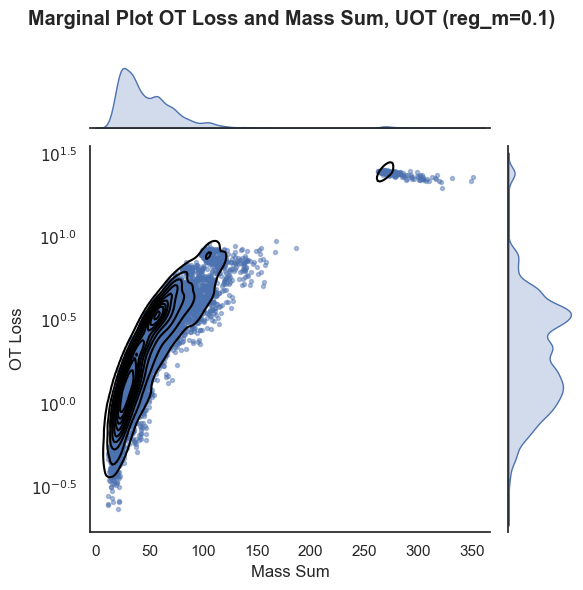

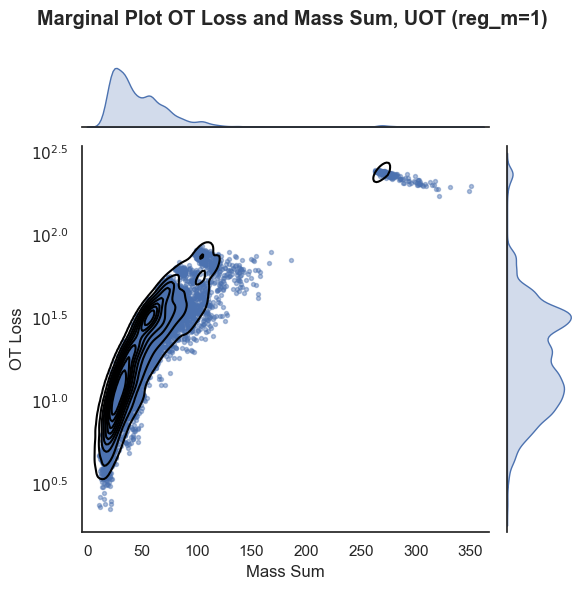

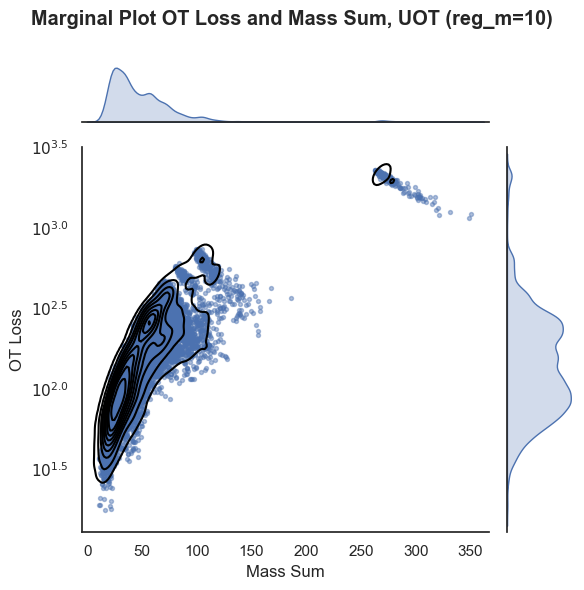

In [69]:
### Mass sum ###
reg_m_list = [0.1, 1, 10]
data_list = [unbalanced_01, unbalanced_1, unbalanced_10]
for data, reg_m in zip(data_list, reg_m_list):
    generate_marginal_plot(data, reg_m)

### Mass Difference

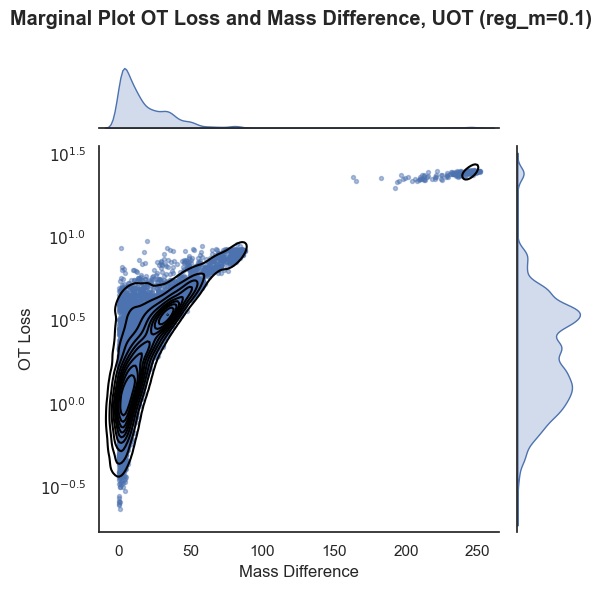

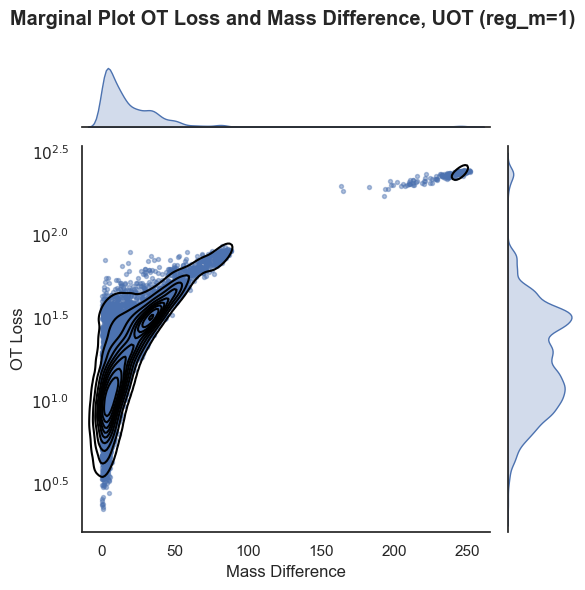

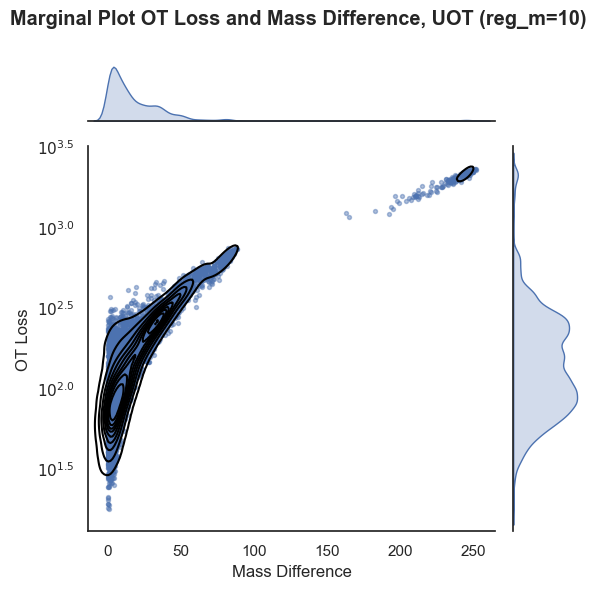

In [70]:
### Mass Difference ###
for data, reg_m in zip(data_list, reg_m_list):
    generate_marginal_plot(data, reg_m, 'diff')

There is a bias. Maybe adapt reg_m on the fly depening on mass difference?

## Removing outlier
Before, this spot of outliers was due to one specific dataset. It would seem logical that the patch of outliers in the marginal plots is also due to this file. To confirm this, we'll remove the entries corresponding to this file and plot accordingly.

In [59]:
### Subsetting data ###
unbalanced_01_trimmed = unbalanced_01[unbalanced_01['row_file'] != 'arc_pair_665109']
unbalanced_01_trimmed = unbalanced_01_trimmed[unbalanced_01_trimmed['col_file'] != 'arc_pair_665109']
unbalanced_1_trimmed = unbalanced_1[unbalanced_1['row_file'] != 'arc_pair_665109']
unbalanced_1_trimmed = unbalanced_1_trimmed[unbalanced_1_trimmed['col_file'] != 'arc_pair_665109']
unbalanced_10_trimmed = unbalanced_10[unbalanced_10['row_file'] != 'arc_pair_665109']
unbalanced_10_trimmed = unbalanced_10_trimmed[unbalanced_10_trimmed['col_file'] != 'arc_pair_665109']

trim_data_list = [unbalanced_01_trimmed, unbalanced_1_trimmed, unbalanced_10_trimmed]

### Mass Sum

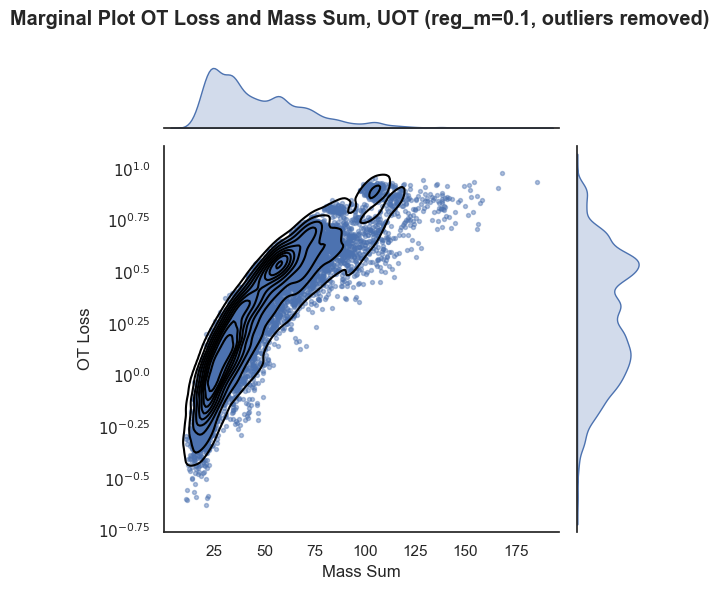

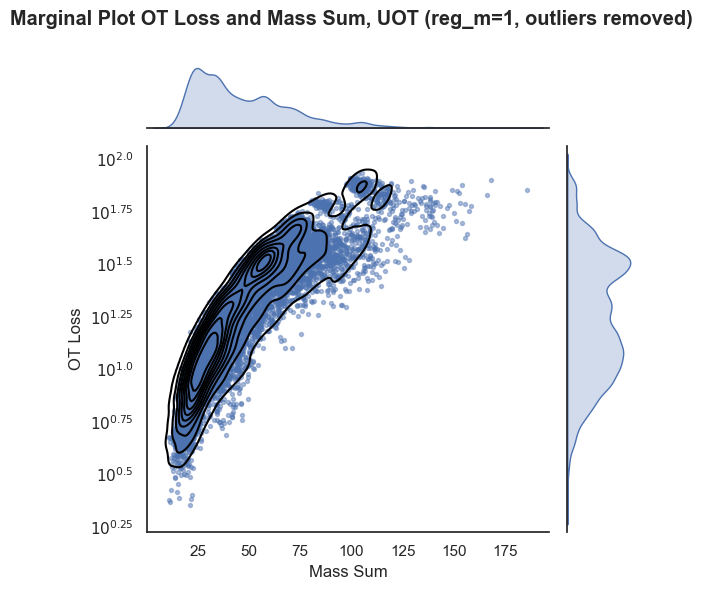

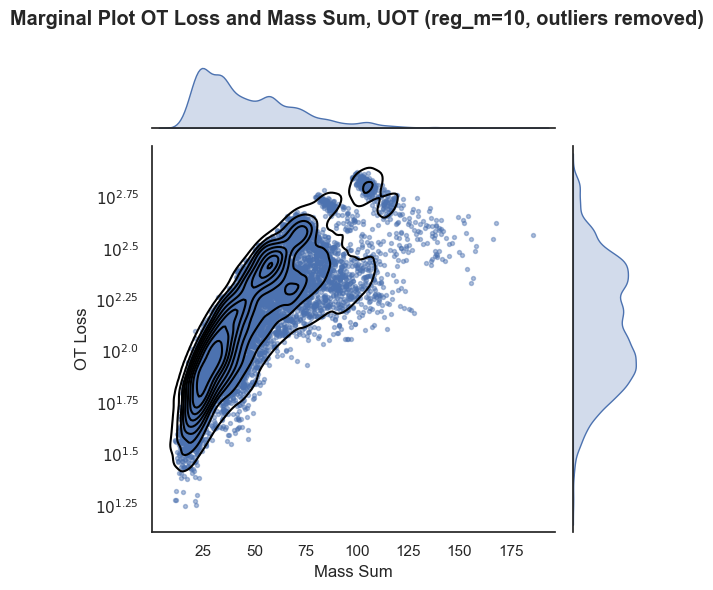

In [ ]:
### Mass Sum ###
for data, reg_m in zip(trim_data_list, reg_m_list):
    generate_marginal_plot(data, reg_m, trim=True)

### Mass Difference

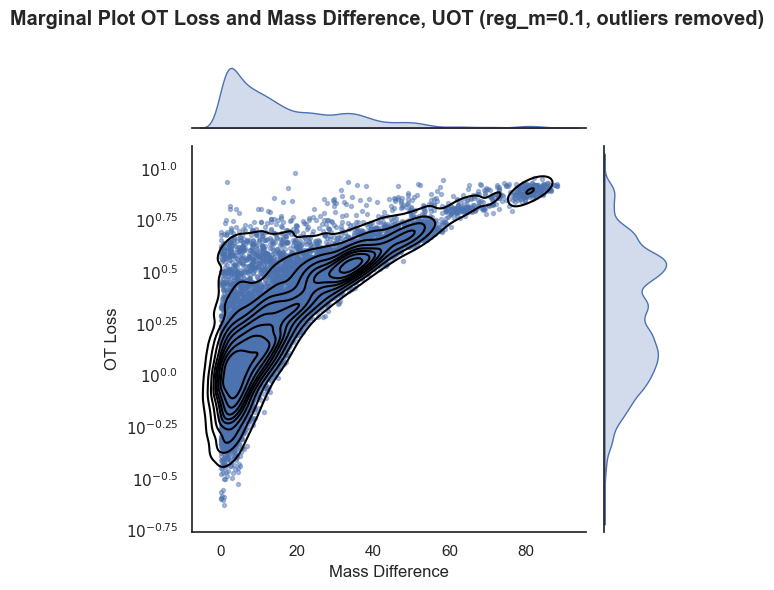

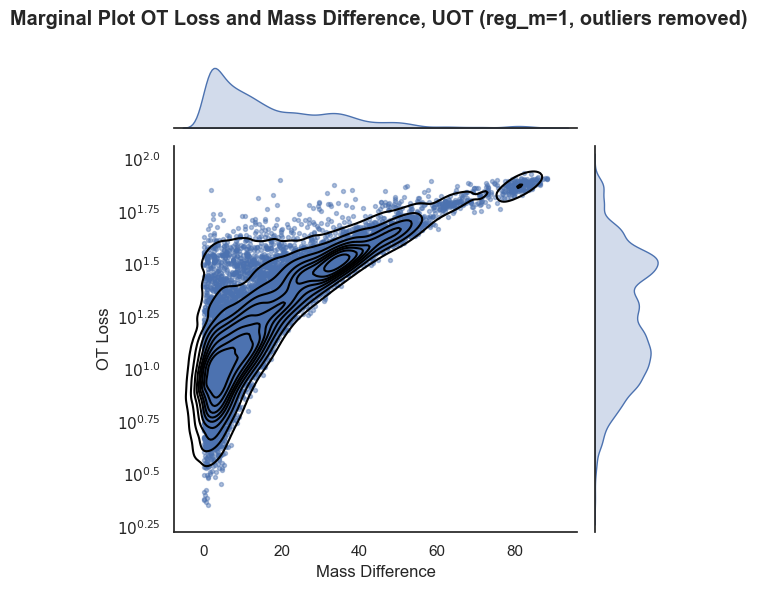

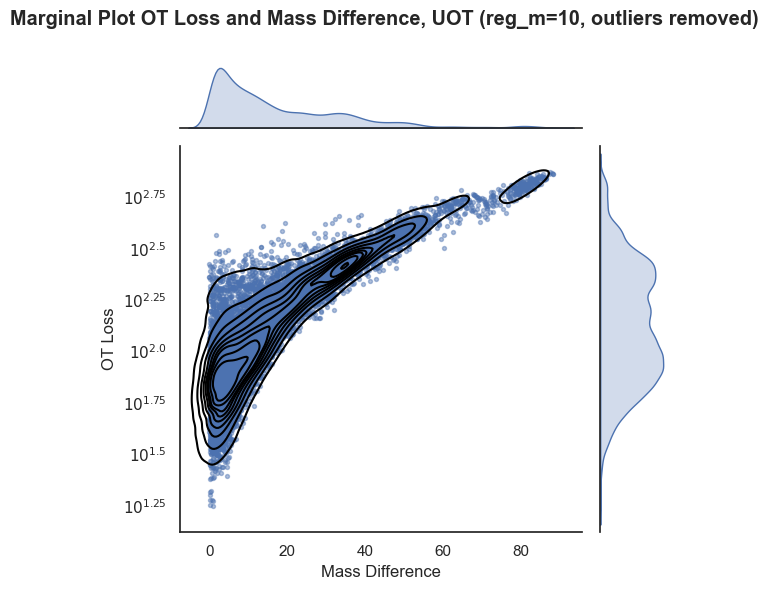

In [72]:
### Mass Diff ###
for data, reg_m in zip(trim_data_list, reg_m_list):
    generate_marginal_plot(data, reg_m, trim=True, kind='diff')